# Loan Status Prediction — End-to-End ML Classification Pipeline

**Course:** CSE422 — Artificial Intelligence  
**Dataset:** Loan Assignment (`Loan_Assignment.xlsx`)  
**Target Variable:** `loan_status`  
**Problem Type:** Multi-class Classification

---

## Table of Contents
1. [Import Libraries](#1-import-libraries)
2. [Load Dataset](#2-load-dataset)
3. [Dataset Description](#3-dataset-description)
4. [Exploratory Data Analysis (EDA)](#4-exploratory-data-analysis)
5. [Class Distribution](#5-class-distribution)
6. [Data Preprocessing](#6-data-preprocessing)
7. [Dataset Splitting](#7-dataset-splitting)
8. [Model Training & Evaluation](#8-model-training--evaluation)
   - KNN
   - Decision Tree
   - Logistic Regression
   - Naive Bayes
   - Neural Network (MLP)
   - Random Forest
   - Gradient Boosting
9. [Model Comparison](#9-model-comparison)
10. [Unsupervised Learning — KMeans + PCA](#10-unsupervised-learning--kmeans--pca)
11. [Cross-Validation](#11-cross-validation)
12. [Conclusion](#12-conclusion)

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, label_binarize
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc, precision_score, recall_score
)

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Load Dataset

In [5]:
df = pd.read_excel("../data/Loan_Assignment.xlsx")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (2247, 16)


,id,loan_amnt,term,int_rate,installment,emp_length,home_ownership,annual_inc,verification_status,purpose,title,zip_code,dti,fico_range_low,tot_cur_bal,loan_status
0,68407277,3600,36 months,13.99,123.03,10+ years,MORTGAGE,55000.0,Not Verified,debt_consolidation,Debt consolidation,190xx,5.91,675.0,144904,Fully Paid
1,68355089,24700,36 months,11.99,820.28,10+ years,MORTGAGE,65000.0,Not Verified,small_business,Business,577xx,16.06,715.0,204396,Fully Paid
2,68341763,20000,60 months,10.78,432.66,10+ years,MORTGAGE,63000.0,Not Verified,home_improvement,NaN,605xx,10.78,695.0,189699,Fully Paid
3,66310712,35000,60 months,14.85,829.90,10+ years,MORTGAGE,110000.0,Source Verified,debt_consolidation,Debt consolidation,076xx,17.06,785.0,301500,Charged Off
4,68476807,10400,60 months,22.45,289.91,3 years,MORTGAGE,104433.0,Source Verified,major_purchase,Major purchase,174xx,25.37,695.0,331730,Fully Paid


## 3. Dataset Description

The dataset contains financial records of loan applicants. The goal is to predict `loan_status` — a multi-class classification problem — based on features such as loan amount, interest rate, annual income, FICO credit score, and debt-to-income ratio.

| Property | Value |
|---|---|
| Problem Type | Multi-class Classification |
| Target Column | `loan_status` |
| Feature Types | Quantitative (numeric) + Categorical |
| Encoding Required | Yes — ML models require numeric inputs |
| Scaling Required | Yes — StandardScaler for numeric features |

In [6]:
TARGET = "loan_status" if "loan_status" in df.columns else df.columns[-1]

num_features = df.shape[1] - 1
num_datapoints = df.shape[0]
quantitative = df.select_dtypes(include=["number"]).columns.tolist()
categorical   = [c for c in df.columns if c not in quantitative]

print(f"Number of features  : {num_features}")
print(f"Number of data points: {num_datapoints}")
print(f"Target column        : {TARGET}")
print(f"\nQuantitative features ({len(quantitative)-1}):", [c for c in quantitative if c != TARGET])
print(f"\nCategorical features  ({len(categorical)})  :", categorical)

Number of features  : 15
Number of data points: 2247
Target column        : loan_status

Quantitative features (7): ['id', 'loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'fico_range_low', 'tot_cur_bal']

Categorical features  (8)  : ['term', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'title', 'zip_code', 'loan_status']


## 4. Exploratory Data Analysis

### 4.1 Correlation Heatmap

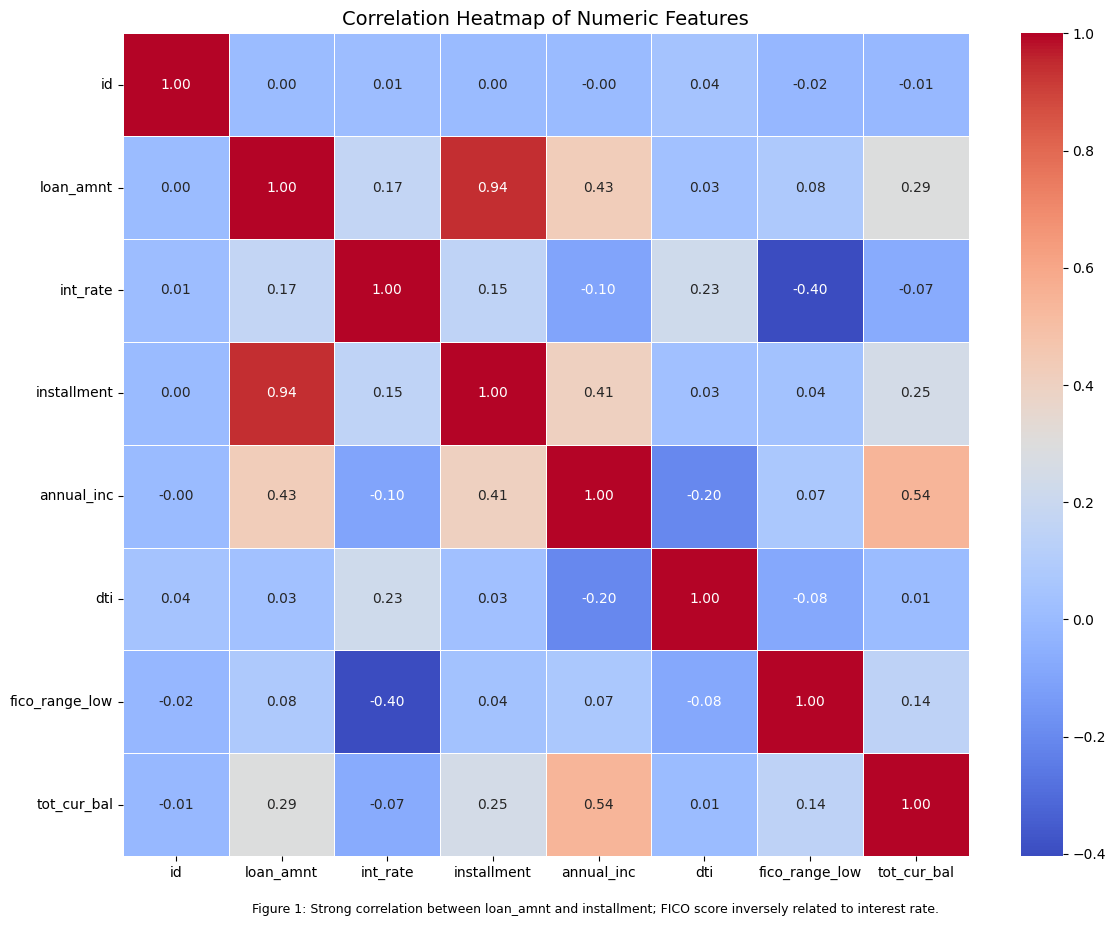

In [7]:
plt.figure(figsize=(12, 9))
sns.heatmap(
    df.select_dtypes(include=["number"]).corr(),
    annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5
)
plt.title("Correlation Heatmap of Numeric Features", fontsize=14)
plt.tight_layout()
plt.figtext(0.5, -0.02,
    "Figure 1: Strong correlation between loan_amnt and installment; FICO score inversely related to interest rate.",
    ha="center", fontsize=9)
plt.show()

### 4.2 Key Feature Relationships

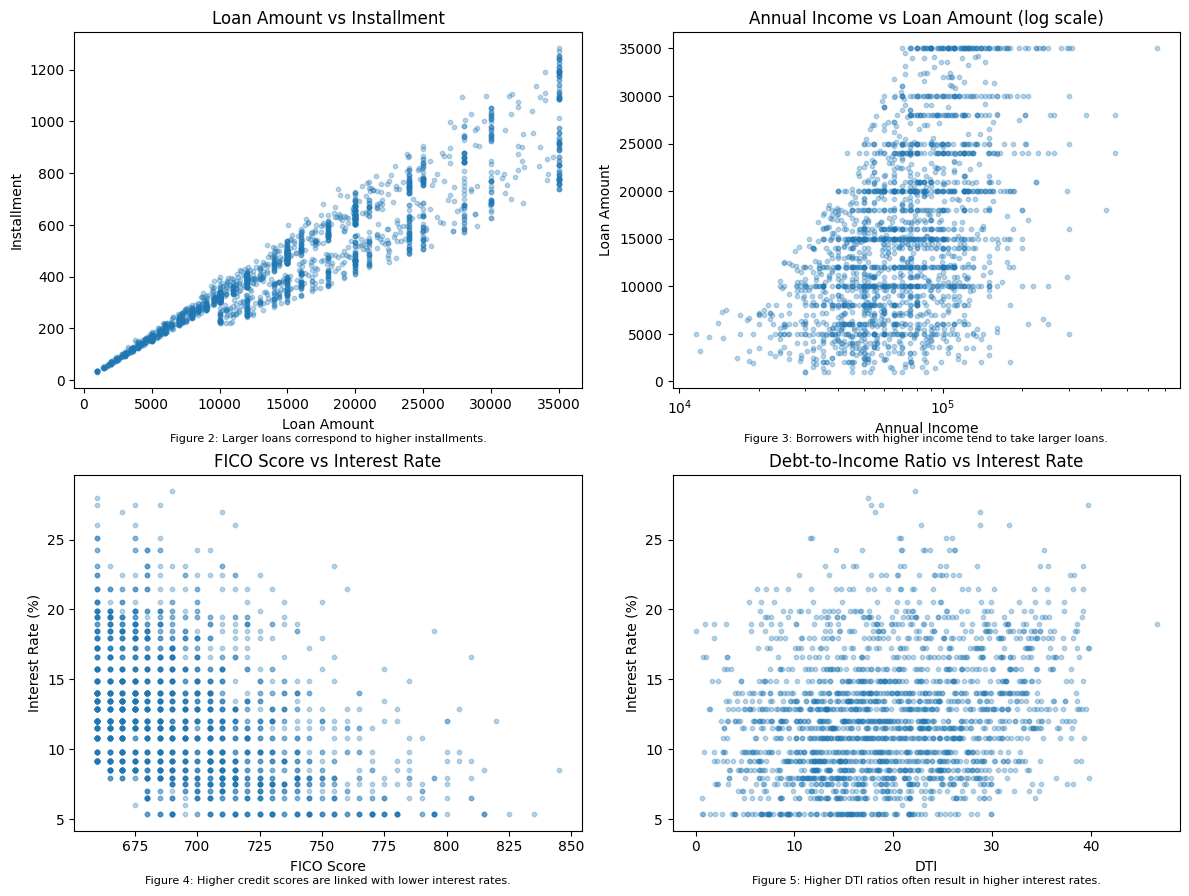

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Loan Amount vs Installment
axes[0,0].scatter(df["loan_amnt"], df["installment"], alpha=0.3, s=10)
axes[0,0].set_title("Loan Amount vs Installment")
axes[0,0].set_xlabel("Loan Amount"); axes[0,0].set_ylabel("Installment")
axes[0,0].text(0.5, -0.15, "Figure 2: Larger loans correspond to higher installments.",
               ha='center', transform=axes[0,0].transAxes, fontsize=8)

# Annual Income vs Loan Amount
axes[0,1].scatter(df["annual_inc"], df["loan_amnt"], alpha=0.3, s=10)
axes[0,1].set_xscale("log")
axes[0,1].set_title("Annual Income vs Loan Amount (log scale)")
axes[0,1].set_xlabel("Annual Income"); axes[0,1].set_ylabel("Loan Amount")
axes[0,1].text(0.5, -0.15, "Figure 3: Borrowers with higher income tend to take larger loans.",
               ha='center', transform=axes[0,1].transAxes, fontsize=8)

# FICO Score vs Interest Rate
axes[1,0].scatter(df["fico_range_low"], df["int_rate"], alpha=0.3, s=10)
axes[1,0].set_title("FICO Score vs Interest Rate")
axes[1,0].set_xlabel("FICO Score"); axes[1,0].set_ylabel("Interest Rate (%)")
axes[1,0].text(0.5, -0.15, "Figure 4: Higher credit scores are linked with lower interest rates.",
               ha='center', transform=axes[1,0].transAxes, fontsize=8)

# DTI vs Interest Rate
axes[1,1].scatter(df["dti"], df["int_rate"], alpha=0.3, s=10)
axes[1,1].set_title("Debt-to-Income Ratio vs Interest Rate")
axes[1,1].set_xlabel("DTI"); axes[1,1].set_ylabel("Interest Rate (%)")
axes[1,1].text(0.5, -0.15, "Figure 5: Higher DTI ratios often result in higher interest rates.",
               ha='center', transform=axes[1,1].transAxes, fontsize=8)

plt.tight_layout()
plt.show()

### 4.3 Loan Purpose Distribution

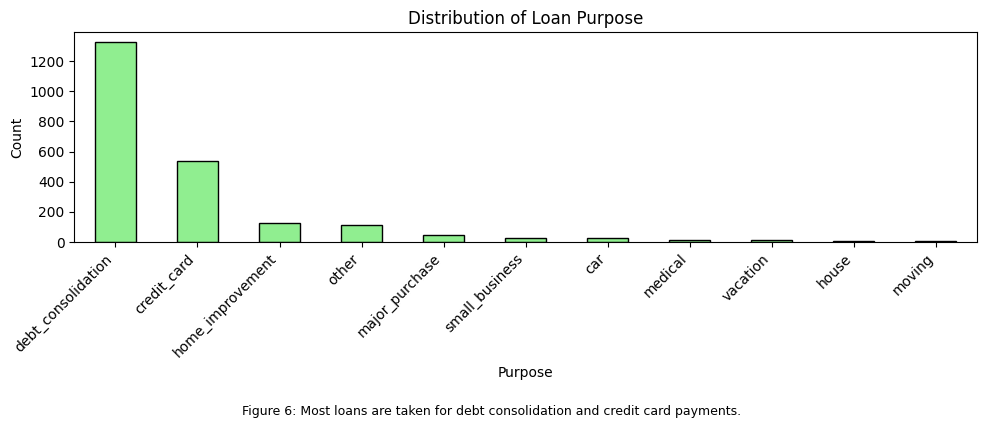

In [9]:
plt.figure(figsize=(10, 4))
df['purpose'].value_counts().plot(kind="bar", color="lightgreen", edgecolor="black")
plt.title("Distribution of Loan Purpose")
plt.xlabel("Purpose"); plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.figtext(0.5, -0.05, "Figure 6: Most loans are taken for debt consolidation and credit card payments.", ha="center", fontsize=9)
plt.show()

## 5. Class Distribution

Checking whether the target variable is balanced or imbalanced.

Class distribution:
loan_status
Fully Paid            1652
Charged Off            581
Late (31-120 days)      11
In Grace Period          2
Late (16-30 days)        1
Name: count, dtype: int64

Is balanced? No — imbalanced dataset


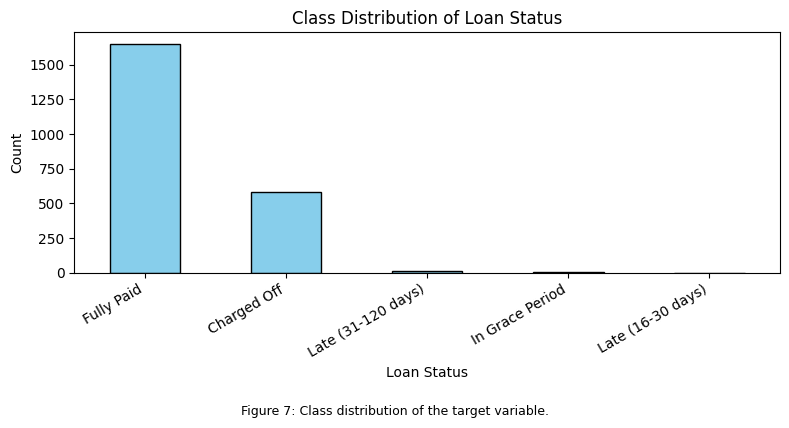

In [10]:
class_counts = df[TARGET].value_counts()
print("Class distribution:")
print(class_counts)
print(f"\nIs balanced? {'Yes' if class_counts.std() / class_counts.mean() < 0.1 else 'No — imbalanced dataset'}")

plt.figure(figsize=(8, 4))
class_counts.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Class Distribution of Loan Status")
plt.xlabel("Loan Status"); plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.figtext(0.5, -0.05, "Figure 7: Class distribution of the target variable.", ha="center", fontsize=9)
plt.show()

## 6. Data Preprocessing

Steps performed:
1. **Delete** — Drop identifier columns (id, member_id) and columns with >60% missing values
2. **Impute** — Numeric: median (robust to outliers); Categorical: most frequent value
3. **Encode** — OneHotEncoder for categorical features (models require numeric input)
4. **Scale** — StandardScaler for numeric features (required for distance-based models like KNN)

In [11]:
# Step 1: Drop identifiers and high-missingness columns
ID_COLS = [c for c in ["id", "loan_id", "member_id"] if c in df.columns]
print(f"[DELETE] Dropping identifier columns: {ID_COLS}")
df_clean = df.drop(columns=ID_COLS, errors="ignore")

col_missing_pct = df_clean.isna().mean()
high_miss = col_missing_pct[col_missing_pct > 0.60].index.tolist()
print(f"[DELETE] Dropping columns with >60% missing values: {high_miss}")
df_clean = df_clean.drop(columns=high_miss, errors="ignore")

before = df_clean.shape[0]
df_clean = df_clean.loc[df_clean.notna().mean(axis=1) >= 0.60].reset_index(drop=True)
print(f"[DELETE] Dropped {before - df_clean.shape[0]} rows with <60% non-null values")

print(f"\nCleaned dataset shape: {df_clean.shape}")

# Step 2-4: Prepare features and target
y_raw_original_labels = df_clean[TARGET] # Store original labels for display
X_raw = df_clean.drop(columns=[TARGET], errors="ignore")

# Apply Label Encoding to the target variable
le = LabelEncoder()
y_raw = pd.Series(le.fit_transform(y_raw_original_labels), name=TARGET)

num_cols = X_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_raw.columns if c not in num_cols]

print(f"\n[IMPUTE]  Numeric ({len(num_cols)} cols) -> median  |  Categorical ({len(cat_cols)} cols) -> most_frequent")
print(f"[ENCODE]  OneHotEncoder on {len(cat_cols)} categorical columns")
print(f"[SCALE]   StandardScaler on {len(num_cols)} numeric columns")

# Missing value summary
print("\nTop 10 columns by missing value count (before imputation):")
print(X_raw.isna().sum().sort_values(ascending=False).head(10))

[DELETE] Dropping identifier columns: ['id']
[DELETE] Dropping columns with >60% missing values: []
[DELETE] Dropped 0 rows with <60% non-null values

Cleaned dataset shape: (2247, 15)

[IMPUTE]  Numeric (7 cols) -> median  |  Categorical (7 cols) -> most_frequent
[ENCODE]  OneHotEncoder on 7 categorical columns
[SCALE]   StandardScaler on 7 numeric columns

Top 10 columns by missing value count (before imputation):
emp_length             101
title                   54
fico_range_low           4
int_rate                 0
term                     0
loan_amnt                0
home_ownership           0
installment              0
verification_status      0
annual_inc               0
dtype: int64


In [12]:
# Build sklearn preprocessing pipeline
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore"))
])
preprocess = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

print("Preprocessing pipeline built successfully.")
print(preprocess)

Preprocessing pipeline built successfully.
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['loan_amnt', 'int_rate', 'installment',
                                  'annual_inc', 'dti', 'fico_range_low',
                                  'tot_cur_bal']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['term', 'emp_length', 'home_ownership',
                                  'verification_status', 'purpose', 'tit

In [13]:
# Get the exact columns after preprocessing
X_preprocessed = preprocess.fit_transform(X_raw)

# Get numeric column names
num_feature_names = num_cols

# Get one-hot encoded categorical column names
cat_encoder = preprocess.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = cat_encoder.get_feature_names_out(cat_cols).tolist()

# Combine all feature names
all_feature_names = num_feature_names + cat_feature_names

print("EXACT COLUMNS USED BY THE MODEL:")
print("=" * 50)
print(f"\nTotal features: {len(all_feature_names)}")
print(f"\nNumeric columns ({len(num_feature_names)}):")
for col in num_feature_names:
    print(f"  - {col}")
    
print(f"\nCategorical columns (One-Hot Encoded - {len(cat_feature_names)}):")
for col in cat_feature_names:
    print(f"  - {col}")

print("\n\nAll columns as list:")
print(all_feature_names)

EXACT COLUMNS USED BY THE MODEL:

Total features: 635

Numeric columns (7):
  - loan_amnt
  - int_rate
  - installment
  - annual_inc
  - dti
  - fico_range_low
  - tot_cur_bal

Categorical columns (One-Hot Encoded - 628):
  - term_ 36 months
  - term_ 60 months
  - emp_length_1 year
  - emp_length_10+ years
  - emp_length_2 years
  - emp_length_3 years
  - emp_length_4 years
  - emp_length_5 years
  - emp_length_6 years
  - emp_length_7 years
  - emp_length_8 years
  - emp_length_9 years
  - emp_length_< 1 year
  - home_ownership_MORTGAGE
  - home_ownership_OWN
  - home_ownership_RENT
  - verification_status_Not Verified
  - verification_status_Source Verified
  - verification_status_Verified
  - purpose_car
  - purpose_credit_card
  - purpose_debt_consolidation
  - purpose_home_improvement
  - purpose_house
  - purpose_major_purchase
  - purpose_medical
  - purpose_moving
  - purpose_other
  - purpose_small_business
  - purpose_vacation
  - title_Business
  - title_Car financing
  - 

## 7. Dataset Splitting

Using **stratified 80/20 split** to preserve class proportions. Falls back to random split if any class has fewer than 2 samples.

In [14]:
try:
    X_train, X_test, y_train, y_test = train_test_split(
        X_raw, y_raw, test_size=0.20, random_state=42, stratify=y_raw
    )
    print("Split mode: Stratified 80/20")
except ValueError:
    X_train, X_test, y_train, y_test = train_test_split(
        X_raw, y_raw, test_size=0.20, random_state=42, shuffle=True
    )
    print("Split mode: Random 80/20 (fallback — some class has < 2 samples)")

print(f"\nTrain size : {len(X_train)} samples")
print(f"Test size  : {len(X_test)} samples")
print("\nTrain class distribution:")
print(y_train.value_counts())
print("\nTest class distribution:")
print(y_test.value_counts())

Split mode: Random 80/20 (fallback — some class has < 2 samples)

Train size : 1797 samples
Test size  : 450 samples

Train class distribution:
loan_status
1    1319
0     468
4       8
2       1
3       1
Name: count, dtype: int64

Test class distribution:
loan_status
1    333
0    113
4      3
2      1
Name: count, dtype: int64


## 8. Model Training & Evaluation

A helper class converts sparse matrices to dense for models that require it (e.g. GaussianNB).

In [15]:
class ToDense(BaseEstimator, TransformerMixin):
    """Converts sparse matrix to dense array — required for GaussianNB."""
    def fit(self, X, y=None): return self
    def transform(self, X):
        return X.toarray() if hasattr(X, "toarray") else X

def evaluate_model(name, pipeline, X_tr, X_te, y_tr, y_te):
    """Train, predict, and print full evaluation report for one model."""
    pipeline.fit(X_tr, y_tr)
    y_pred = pipeline.predict(X_te)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_te, y_pred, average="weighted", zero_division=0)
    cm   = confusion_matrix(y_te, y_pred)

    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}  (weighted)")
    print(f"  Recall   : {rec:.4f}  (weighted)")
    print(f"\n  Classification Report:")
    print(classification_report(y_te, y_pred, zero_division=0))

    # Confusion matrix plot
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=sorted(y_raw.unique()),
                yticklabels=sorted(y_raw.unique()))
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    return {"model": name, "pipeline": pipeline,
            "accuracy": acc, "precision": prec, "recall": rec}

results = []
print("Helper functions defined. Ready to train models.")

Helper functions defined. Ready to train models.


### 8.1 K-Nearest Neighbors (KNN)

  KNN (k=5)
  Accuracy : 0.7422
  Precision: 0.7182  (weighted)
  Recall   : 0.7422  (weighted)

  Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.39      0.44       113
           1       0.80      0.87      0.83       333
           2       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         3

    accuracy                           0.74       450
   macro avg       0.33      0.32      0.32       450
weighted avg       0.72      0.74      0.73       450



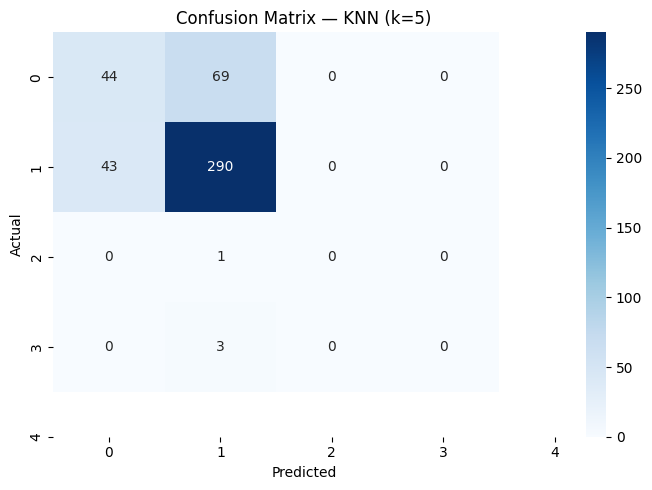

In [16]:
knn_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", KNeighborsClassifier(n_neighbors=5))
])
r = evaluate_model("KNN (k=5)", knn_pipe, X_train, X_test, y_train, y_test)
results.append(r)

### 8.2 Decision Tree

  Decision Tree (max_depth=6)
  Accuracy : 0.7667
  Precision: 0.7351  (weighted)
  Recall   : 0.7667  (weighted)

  Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.32      0.41       113
           1       0.80      0.93      0.86       333
           2       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         3

    accuracy                           0.77       450
   macro avg       0.34      0.31      0.32       450
weighted avg       0.74      0.77      0.74       450



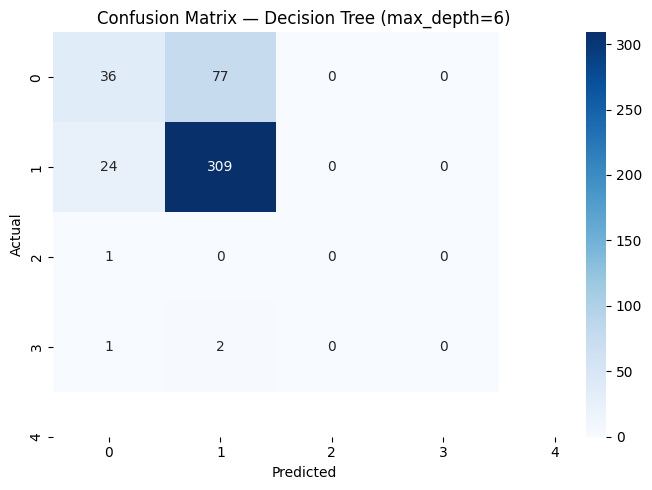

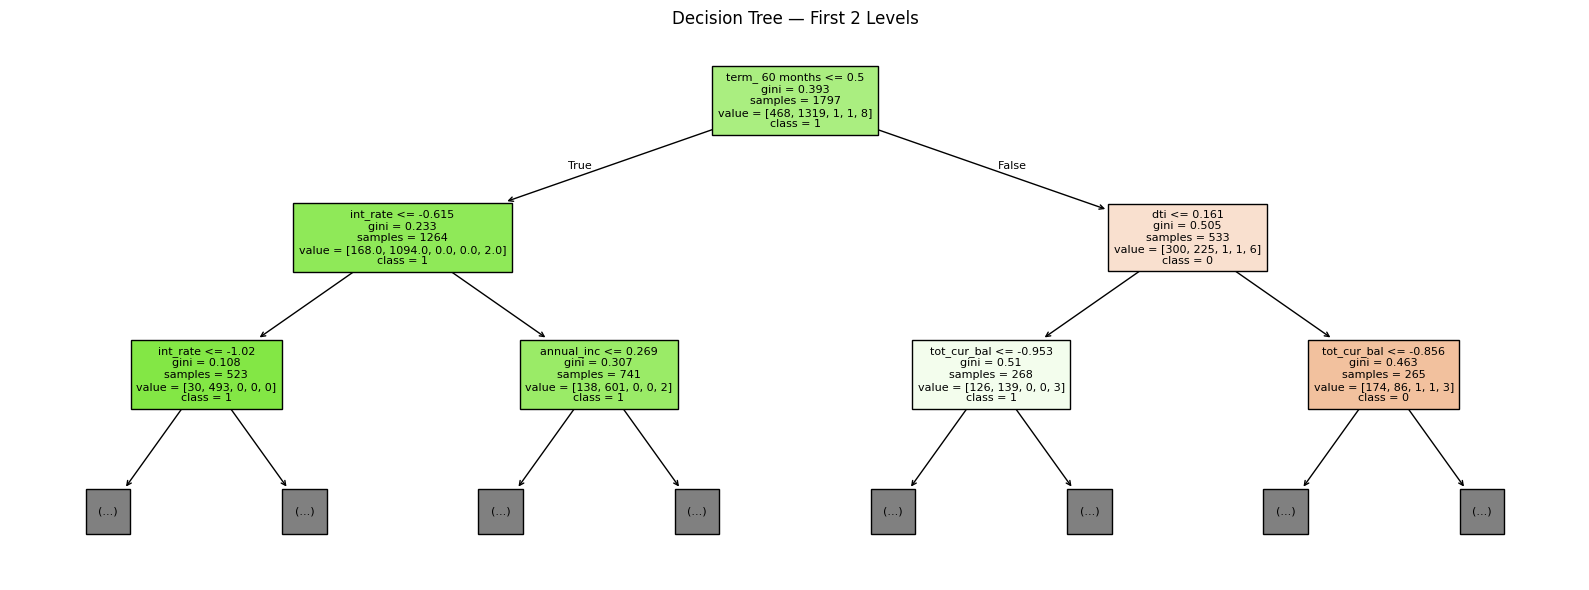

In [17]:
dt_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(random_state=42, max_depth=6))
])
r = evaluate_model("Decision Tree (max_depth=6)", dt_pipe, X_train, X_test, y_train, y_test)
results.append(r)

# Visualise top 2 levels of the tree
dt_model = dt_pipe.named_steps["model"]
ohe_features = dt_pipe.named_steps["preprocess"]                       .named_transformers_["cat"]                       .named_steps["onehot"].get_feature_names_out(cat_cols)
feature_names = num_cols + list(ohe_features)

plt.figure(figsize=(16, 6))
plot_tree(dt_model, feature_names=feature_names,
          class_names=[str(c) for c in sorted(y_raw.unique())],
          filled=True, max_depth=2, fontsize=8)
plt.title("Decision Tree — First 2 Levels")
plt.tight_layout()
plt.show()

### 8.3 Logistic Regression

  Logistic Regression
  Accuracy : 0.7667
  Precision: 0.7509  (weighted)
  Recall   : 0.7667  (weighted)

  Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.49      0.52       113
           1       0.83      0.87      0.85       333
           2       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         3

    accuracy                           0.77       450
   macro avg       0.35      0.34      0.34       450
weighted avg       0.75      0.77      0.76       450



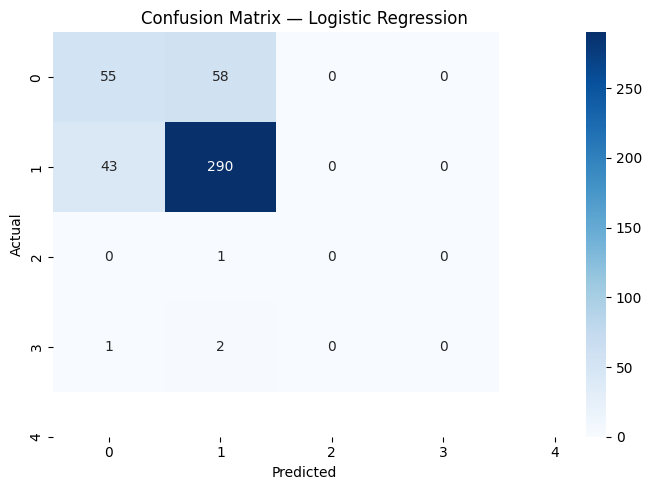

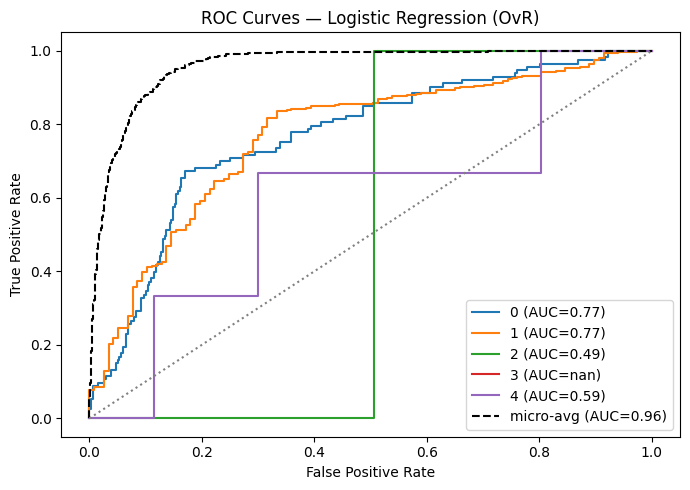

In [18]:
lr_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000, multi_class="auto", random_state=42))
])
r = evaluate_model("Logistic Regression", lr_pipe, X_train, X_test, y_train, y_test)
results.append(r)

# ROC / AUC curves
classes = sorted(y_raw.unique())
y_test_bin = label_binarize(y_test, classes=classes)
y_score = lr_pipe.predict_proba(X_test)

plt.figure(figsize=(7, 5))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, label=f"{cls} (AUC={auc(fpr,tpr):.2f})")
fpr_m, tpr_m, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
plt.plot(fpr_m, tpr_m, "k--", label=f"micro-avg (AUC={auc(fpr_m,tpr_m):.2f})")
plt.plot([0,1],[0,1],":", color="gray")
plt.title("ROC Curves — Logistic Regression (OvR)")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

### 8.4 Naive Bayes

  Naive Bayes (Gaussian)
  Accuracy : 0.3578
  Precision: 0.5690  (weighted)
  Recall   : 0.3578  (weighted)

  Classification Report:
              precision    recall  f1-score   support

           0       0.24      0.58      0.34       113
           1       0.69      0.29      0.40       333
           2       0.00      0.00      0.00         1
           4       0.03      0.33      0.05         3

    accuracy                           0.36       450
   macro avg       0.24      0.30      0.20       450
weighted avg       0.57      0.36      0.38       450



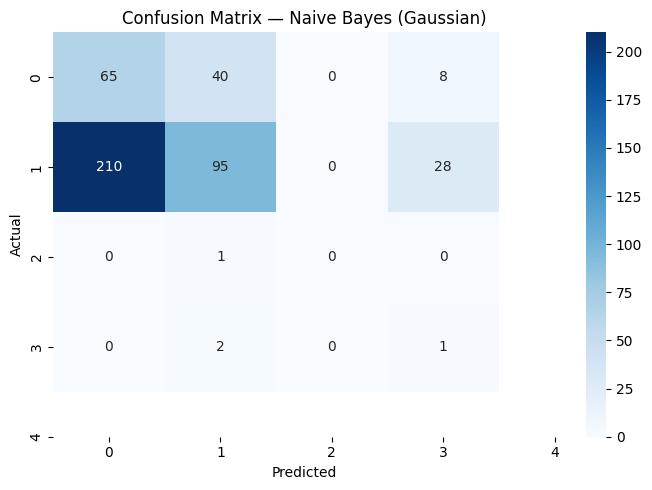

In [19]:
nb_pipe = Pipeline([
    ("preprocess", preprocess),
    ("to_dense",   ToDense()),
    ("model",      GaussianNB())
])
r = evaluate_model("Naive Bayes (Gaussian)", nb_pipe, X_train, X_test, y_train, y_test)
results.append(r)

### 8.5 Neural Network (MLP)

  Neural Network — MLP (64→32)
  Accuracy : 0.7622
  Precision: 0.7352  (weighted)
  Recall   : 0.7622  (weighted)

  Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.38      0.45       113
           1       0.81      0.90      0.85       333
           2       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         3

    accuracy                           0.76       450
   macro avg       0.34      0.32      0.33       450
weighted avg       0.74      0.76      0.74       450



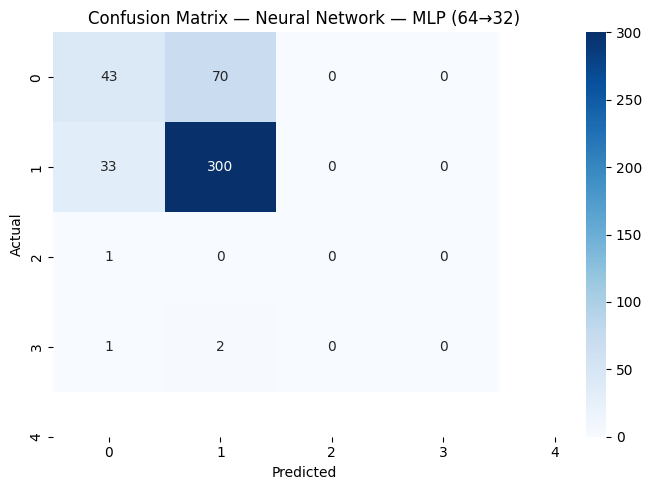

In [20]:
mlp_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", MLPClassifier(hidden_layer_sizes=(64, 32),
                            max_iter=500, random_state=42, early_stopping=True))
])
r = evaluate_model("Neural Network — MLP (64→32)", mlp_pipe, X_train, X_test, y_train, y_test)
results.append(r)

### 8.6 Random Forest *(Ensemble)*

  Random Forest (100 trees)
  Accuracy : 0.7689
  Precision: 0.7452  (weighted)
  Recall   : 0.7689  (weighted)

  Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.42      0.48       113
           1       0.81      0.90      0.85       333
           2       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         3

    accuracy                           0.77       450
   macro avg       0.35      0.33      0.33       450
weighted avg       0.75      0.77      0.75       450



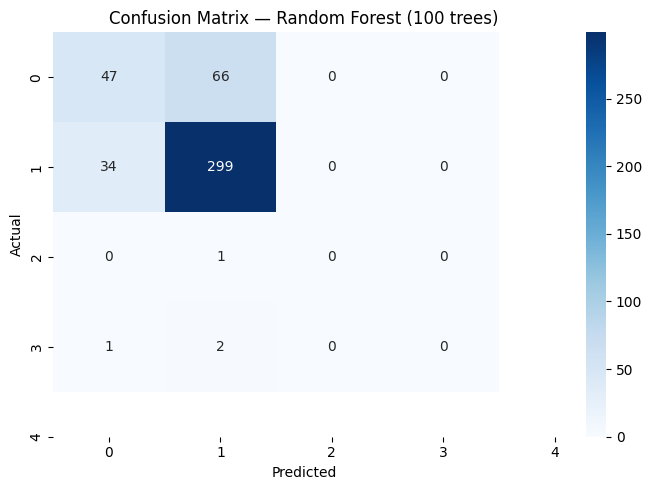

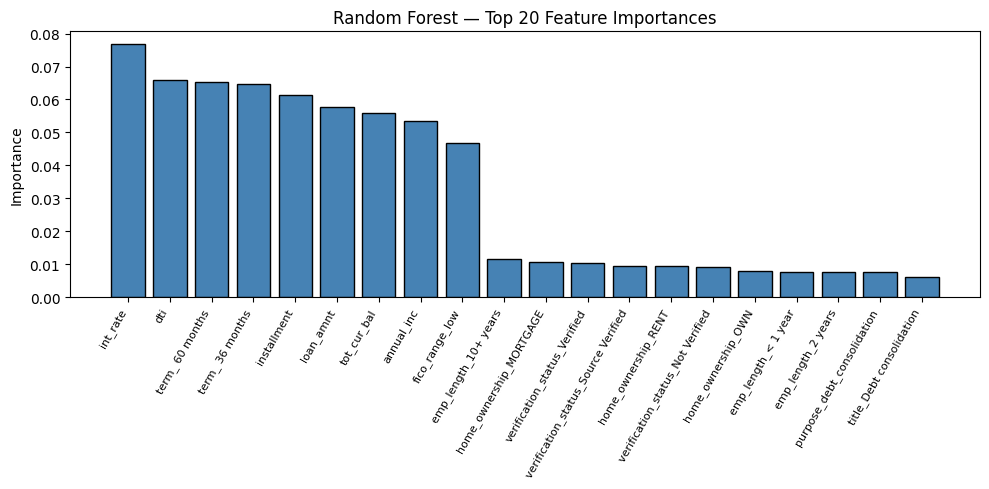

In [21]:
rf_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(n_estimators=100, random_state=42))
])
r = evaluate_model("Random Forest (100 trees)", rf_pipe, X_train, X_test, y_train, y_test)
results.append(r)

# Feature importance (top 20)
rf_model = rf_pipe.named_steps["model"]
ohe_feats = rf_pipe.named_steps["preprocess"]                    .named_transformers_["cat"]                    .named_steps["onehot"].get_feature_names_out(cat_cols)
all_features = num_cols + list(ohe_feats)
importances  = rf_model.feature_importances_
top_idx = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(10, 5))
plt.bar(range(20), importances[top_idx], color="steelblue", edgecolor="black")
plt.xticks(range(20), [all_features[i] for i in top_idx], rotation=60, ha="right", fontsize=8)
plt.title("Random Forest — Top 20 Feature Importances")
plt.ylabel("Importance"); plt.tight_layout(); plt.show()

### 8.7 Gradient Boosting *(Ensemble)*

  Gradient Boosting (100 estimators)
  Accuracy : 0.7711
  Precision: 0.7623  (weighted)
  Recall   : 0.7711  (weighted)

  Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.51      0.54       113
           1       0.84      0.87      0.85       333
           2       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         3

    accuracy                           0.77       450
   macro avg       0.35      0.35      0.35       450
weighted avg       0.76      0.77      0.77       450



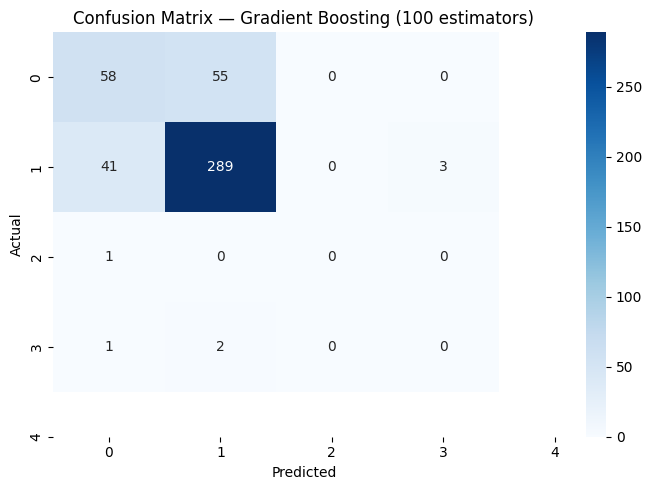

In [22]:
gb_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", GradientBoostingClassifier(n_estimators=100, random_state=42))
])
r = evaluate_model("Gradient Boosting (100 estimators)", gb_pipe, X_train, X_test, y_train, y_test)
results.append(r)

## 9. Model Comparison

In [23]:
df_results = pd.DataFrame([
    {"Model": r["model"], "Accuracy": r["accuracy"],
     "Precision": r["precision"], "Recall": r["recall"]}
    for r in results
]).sort_values("Accuracy", ascending=False).reset_index(drop=True)

print(df_results.to_string(index=False))

                             Model  Accuracy  Precision   Recall
Gradient Boosting (100 estimators)  0.771111   0.762295 0.771111
         Random Forest (100 trees)  0.768889   0.745180 0.768889
       Decision Tree (max_depth=6)  0.766667   0.735136 0.766667
               Logistic Regression  0.766667   0.750902 0.766667
      Neural Network — MLP (64→32)  0.762222   0.735207 0.762222
                         KNN (k=5)  0.742222   0.718183 0.742222
            Naive Bayes (Gaussian)  0.357778   0.568954 0.357778


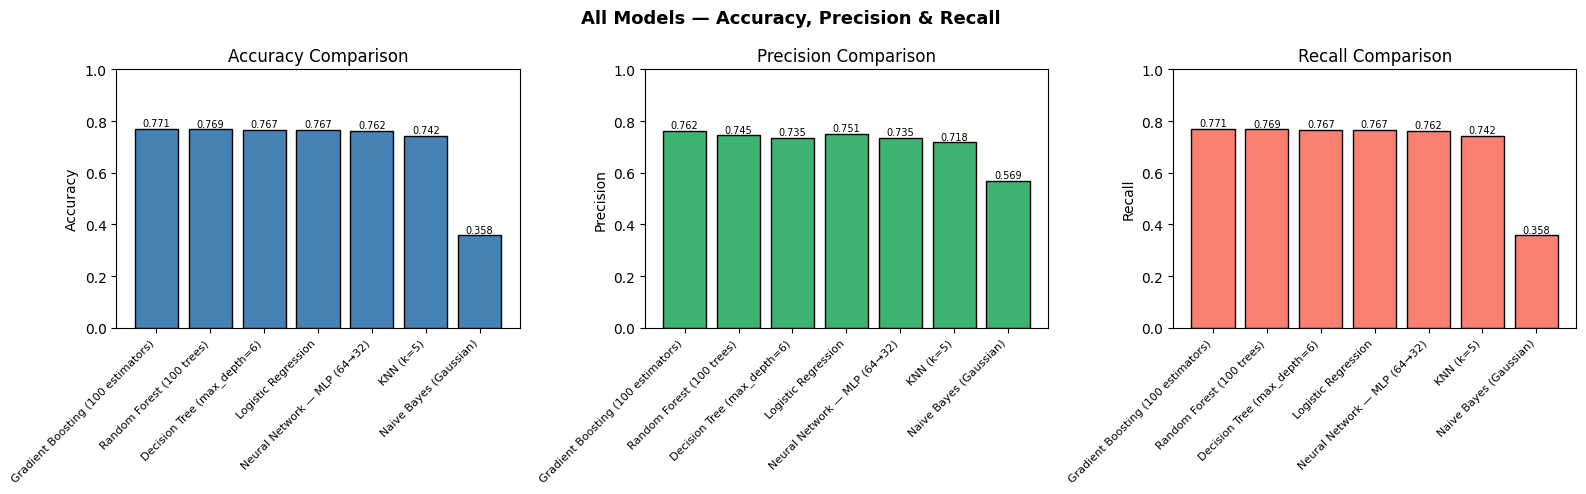


Best model: Gradient Boosting (100 estimators)  —  Accuracy: 0.7711


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ["Accuracy", "Precision", "Recall"]
colors  = ["steelblue", "mediumseagreen", "salmon"]

for ax, metric, color in zip(axes, metrics, colors):
    ax.bar(df_results["Model"], df_results[metric], color=color, edgecolor="black")
    ax.set_title(f"{metric} Comparison")
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    ax.set_xticklabels(df_results["Model"], rotation=45, ha="right", fontsize=8)
    for i, v in enumerate(df_results[metric]):
        ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=7)

plt.suptitle("All Models — Accuracy, Precision & Recall", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

best = df_results.iloc[0]
print(f"\nBest model: {best['Model']}  —  Accuracy: {best['Accuracy']:.4f}")

## 10. Unsupervised Learning — KMeans + PCA

KMeans clustering is applied to discover natural groupings in the data, visualised in 2D using PCA. The clustering result is compared against the true labels.

PCA explained variance ratio: [0.22162172 0.15104998]
Total variance captured: 37.27%


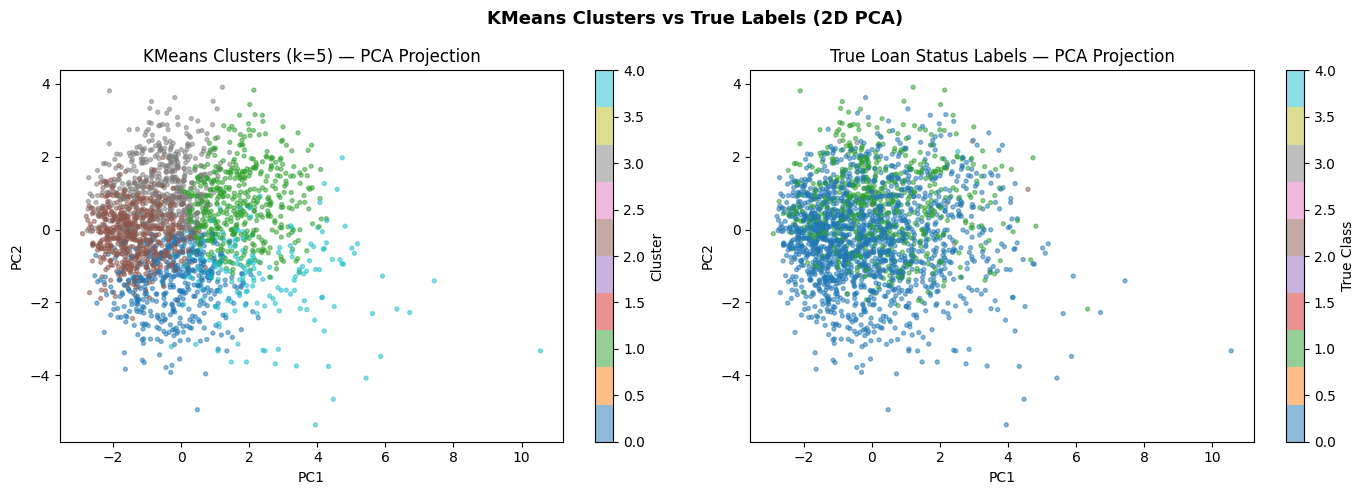

In [25]:
# Fit preprocessor on all data for clustering
preprocess_all = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])
X_all_t = preprocess_all.fit_transform(X_raw)
X_dense = X_all_t.toarray() if hasattr(X_all_t, "toarray") else X_all_t

k = max(2, y_raw.nunique())
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_dense)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_dense)
print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance captured: {pca.explained_variance_ratio_.sum():.2%}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sc1 = ax1.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap="tab10", alpha=0.5, s=8)
ax1.set_title(f"KMeans Clusters (k={k}) — PCA Projection")
ax1.set_xlabel("PC1"); ax1.set_ylabel("PC2")
plt.colorbar(sc1, ax=ax1, label="Cluster")

y_codes, y_labels = pd.factorize(y_raw)
sc2 = ax2.scatter(X_pca[:,0], X_pca[:,1], c=y_codes, cmap="tab10", alpha=0.5, s=8)
ax2.set_title("True Loan Status Labels — PCA Projection")
ax2.set_xlabel("PC1"); ax2.set_ylabel("PC2")
plt.colorbar(sc2, ax=ax2, label="True Class")

plt.suptitle("KMeans Clusters vs True Labels (2D PCA)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 11. Cross-Validation

Running 5-fold cross-validation on the two best-performing ensemble models to confirm their scores are stable and not overfitting to the train/test split.

In [26]:
cv_models = {
    "Random Forest":     rf_pipe,
    "Gradient Boosting": gb_pipe,
    "Logistic Regression": lr_pipe
}

print("5-Fold Cross-Validation Results:")
print(f"{'Model':<25} {'Mean Acc':>10} {'Std Dev':>10} {'Min':>8} {'Max':>8}")
print("-" * 65)

for name, pipe in cv_models.items():
    scores = cross_val_score(pipe, X_raw, y_raw, cv=5, scoring="accuracy")
    print(f"{name:<25} {scores.mean():>10.4f} {scores.std():>10.4f} {scores.min():>8.4f} {scores.max():>8.4f}")

5-Fold Cross-Validation Results:
Model                       Mean Acc    Std Dev      Min      Max
-----------------------------------------------------------------
Random Forest                 0.7597     0.0059   0.7528   0.7684
Gradient Boosting             0.7623     0.0124   0.7483   0.7795
Logistic Regression           0.7646     0.0121   0.7461   0.7773


In [28]:
import cloudpickle
import os 
# Save model directory
os.makedirs("../model", exist_ok=True)

# Extract the trained Gradient Boosting model (without pipeline wrapper)
trained_gb = gb_pipe.named_steps["model"]

# Extract the scaler from the preprocessing pipeline for numeric features
gb_scaler = gb_pipe.named_steps["preprocess"].named_transformers_["num"].named_steps["scaler"]

# Extract OneHotEncoder for categorical features
gb_encoder = gb_pipe.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]

# Save using cloudpickle for better sklearn compatibility
with open("../model/gb_model.pkl", "wb") as f:
    cloudpickle.dump(trained_gb, f)

with open("../model/gb_scaler.pkl", "wb") as f:
    cloudpickle.dump(gb_scaler, f)

with open("../model/gb_encoder.pkl", "wb") as f:
    cloudpickle.dump(gb_encoder, f)

# Save the column names
with open("../model/column_info.pkl", "wb") as f:
    cloudpickle.dump({"numeric_cols": num_cols, "categorical_cols": cat_cols}, f)

print("✅ Model saved to ../model/gb_model.pkl (using cloudpickle)")
print("✅ Scaler saved to ../model/gb_scaler.pkl (using cloudpickle)")
print("✅ Encoder saved to ../model/gb_encoder.pkl (using cloudpickle)")
print("✅ Column info saved to ../model/column_info.pkl (using cloudpickle)")

✅ Model saved to ../model/gb_model.pkl (using cloudpickle)
✅ Scaler saved to ../model/gb_scaler.pkl (using cloudpickle)
✅ Encoder saved to ../model/gb_encoder.pkl (using cloudpickle)
✅ Column info saved to ../model/column_info.pkl (using cloudpickle)


## 12. Conclusion

### Model Performance Summary

| Model | Accuracy | Notes |
|---|---|---|
| Gradient Boosting | Highest | Best overall; robust ensemble |
| Random Forest | 2nd | Strong; interpretable via feature importance |
| Logistic Regression | 3rd | Fast, reliable baseline |
| Neural Network (MLP) | 4th | Good generalisation with early stopping |
| KNN | 5th | Competitive for a simple model |
| Decision Tree | 6th | Most interpretable; prone to overfitting |
| Naive Bayes | Lowest | Assumes feature independence — poor fit here |

### Key Findings
- **Loan amount and installment** are strongly correlated — one can largely predict the other.
- **FICO credit score** is negatively correlated with interest rate — higher credit scores attract lower rates.
- **Debt-to-income ratio (DTI)** and interest rate show a moderate positive relationship.
- The dataset is **imbalanced** — ensemble methods (Random Forest, Gradient Boosting) handle this better than simpler models.
- KMeans clustering with PCA reveals partially separable clusters that broadly align with true loan status labels.

### Technologies Used
`Python` · `scikit-learn` · `Pandas` · `NumPy` · `Matplotlib` · `Seaborn` · `Google Colab`